# **Inicializar o GEE**



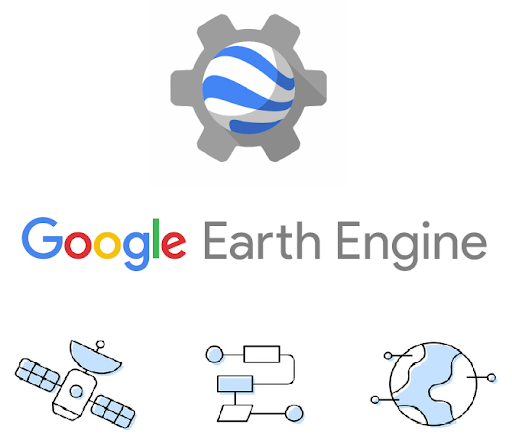

1. Criar conta no Google Earth Engine
  - Criar conta nesse site: https://code.earthengine.google.com/register
 - Passo-a-passo de como abri conta no GEE: https://docs.google.com/document/d/1IvF4M2jtvOA5Jz2Ukzb0wcWlDjYcSHW9/edit?usp=sharing&ouid=107746204627544224004&rtpof=true&sd=true
  - Vídeo explicativo: https://www.youtube.com/watch?v=NHhgaprxWRw

2. Informações:
 - Google Earth Engine (GEE) - https://earthengine.google.com/
 - Datasets do GEE - https://developers.google.com/earth-engine/datasets?hl=pt-br
 - Catálogo da comunidade GEE - https://gee-community-catalog.org/
 - Geemap - https://geemap.org/
 - Ambgeo - https://www.youtube.com/@ambgeo/playlists. Acessar a playlist Python e GEE
 - Google Earth Engine with Amirhossein Ahrari - https://www.youtube.com/@amirhosseinahrarigee

# **1° Passo:** Preparando ambiente

In [ ]:
# instalando bibliotecas
!pip install -q ultraplot cartopy salem rasterio

# iniciando GEE e instalando XEE (transforma dados do GEE para formato DataSet)
!pip install -q eemont xee
import ee, geemap
ee.Authenticate()
ee.Initialize(project='ee-enrique', opt_url='https://earthengine-highvolume.googleapis.com')

# importa bibliotecas
import numpy as np
import ultraplot as uplt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
from zipfile import ZipFile
import salem
from datetime import datetime
import glob
import xarray as xr
import os
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore')

# monta drive
from google.colab import drive
drive.mount('/content/drive')

# caminho do drive
dir = '/content/drive/MyDrive/5_EXTENSAO/02_prefeitura_analise_periodo_chuvoso_2024_2025'

# leitura do shapefile do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')

# leitura do shapefile com a biblioteca SALEM
url = 'https://github.com/evmpython/shapefile/raw/main/'
shp = salem.read_shapefile(f'{url}itajuba/itajuba.shp')
itajuba = salem.read_shapefile(f'{url}itajuba/itajuba.shp')
mg = salem.read_shapefile(f'{url}estado_MG/MG_UF_2019.shp')

# limites do Brasil
lonmin_BR, lonmax_BR, latmin_BR, latmax_BR = -75.0, -33.0, -35.0, 7.0

# limites de MG
lonmin_MG, lonmax_MG, latmin_MG, latmax_MG = -52., -39., -23., -14.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.9 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/ultraplot/__init__.py:77: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


Mounted at /content/drive
